In [1]:
import h5py
from matplotlib import pyplot as plt

In [2]:
ls Space_convergence_qbd\FCT


 Volume in drive C is OS
 Volume Serial Number is 2280-9994

 Directory of C:\Users\12254\Downloads\SIAM_GS\Tracy_convergence\Space_convergence_qbd\FCT

12/04/2025  11:31 AM    <DIR>          .
12/04/2025  12:37 PM    <DIR>          ..
12/04/2025  11:31 AM    <DIR>          ref_0
12/04/2025  11:30 AM    <DIR>          ref_1
12/04/2025  11:27 AM    <DIR>          ref_2
12/04/2025  11:21 AM    <DIR>          ref_3
12/04/2025  10:48 AM    <DIR>          ref_4
               0 File(s)              0 bytes
               7 Dir(s)  101,405,642,752 bytes free


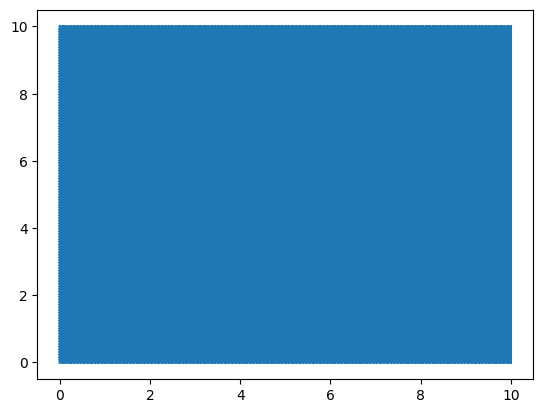

In [3]:
f = h5py.File('Space_convergence_qbd/FCT/ref_4/re_vgm_sand_10x10m_2d.h5', 'r')
elements = f['elementsSpatial_Domain0'][:]
nodes = f['nodesSpatial_Domain0'][:]
psi = f['pressure_head_t0'][:]
plt.triplot(nodes[:,0],nodes[:,1],elements)

In [1]:
import xml.etree.ElementTree as ET
f = h5py.File('Space_convergence_qbd/FCT/ref_4/re_vgm_sand_10x10m_2d.h5', 'r')
root= ET.fromstring(f['Mesh_Spatial_Domain_10000'][:])
root.findall('Time')[0].attrib

NameError: name 'h5py' is not defined

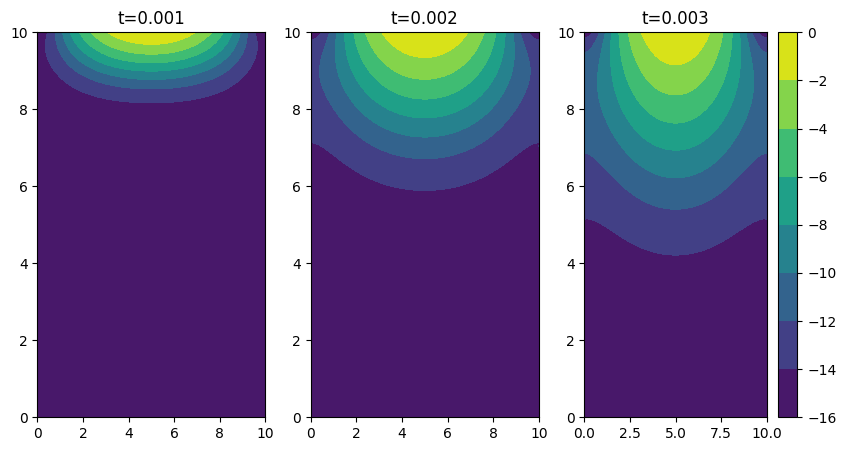

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,5))
f = h5py.File('Space_convergence_qbd/FCT/ref_4/re_vgm_sand_10x10m_2d.h5', 'r')
elements_ref2 = f['elementsSpatial_Domain0'][:]
nodes_ref2 = f['nodesSpatial_Domain0'][:]
psi_ref2 = f['pressure_head_t0'][:]
psi0_ref2  = f['pressure_head_t{0}'.format(1000)][:]
psi5_ref2  = f['pressure_head_t{0}'.format(5000)][:]
psi10_ref2 = f['pressure_head_t{0}'.format(10000)][:]



ax1.tricontourf(nodes_ref2[:,0],nodes_ref2[:,1],elements_ref2,psi0_ref2)
ax2.tricontourf(nodes_ref2[:,0],nodes_ref2[:,1],elements_ref2,psi5_ref2)
tcf3= ax3.tricontourf(nodes_ref2[:,0],nodes_ref2[:,1],elements_ref2,psi10_ref2)

ax1.set_title('t=0.001')
ax2.set_title('t=0.002')
ax3.set_title('t=0.003')
fig.colorbar(tcf3, ax= ax3)

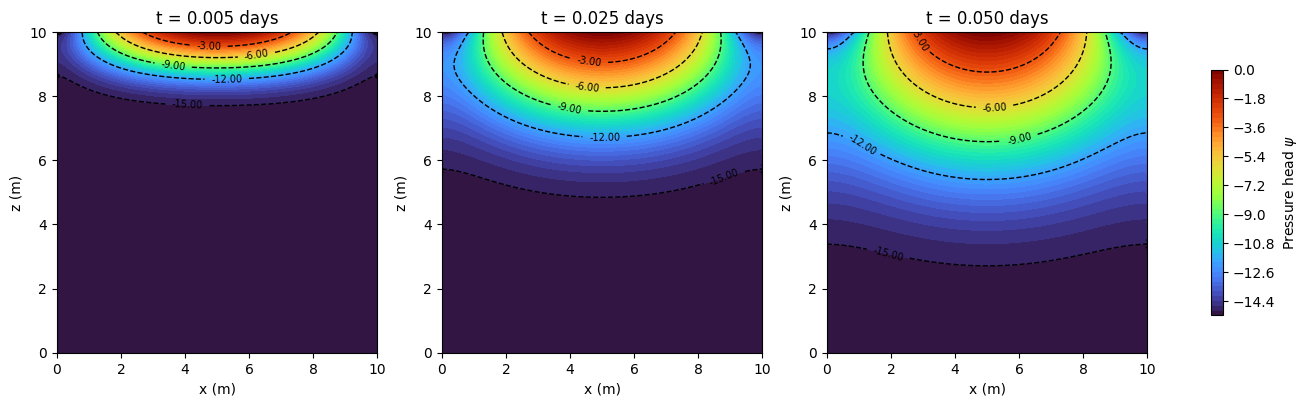

In [42]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

# ---------------- Load data ----------------
h5_path = 'Space_convergence_qbd/FCT/ref_4/re_vgm_sand_10x10m_2d.h5'
f = h5py.File(h5_path, 'r')

elements = f['elementsSpatial_Domain0'][:]
nodes    = f['nodesSpatial_Domain0'][:]

psi0  = f['pressure_head_t1000'][:]
psi5  = f['pressure_head_t5000'][:]
psi10 = f['pressure_head_t10000'][:]

x = nodes[:, 0]
z = nodes[:, 1]

# ---------------- Extract physical times ----------------
def get_time(idx):
    root = ET.fromstring(f[f'Mesh_Spatial_Domain_{idx}'][:])
    return float(root.findall('Time')[0].attrib['Value'])

t0  = get_time(1000)
t5  = get_time(5000)
t10 = get_time(10000)

# ---------------- Shared color scaling ----------------
vmin = min(psi0.min(), psi5.min(), psi10.min())
vmax = max(psi0.max(), psi5.max(), psi10.max())

# ---------------- Plot ----------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5), constrained_layout=True)

# --- panel 1 ---
tcf1 = ax1.tricontourf(x, z, elements, psi0,levels=50, cmap='turbo', vmin=vmin, vmax=vmax)
cs1 = ax1.tricontour(x, z, elements, psi0,levels=5, colors='k', linewidths=1.0)
ax1.clabel(cs1, inline=True, fontsize=7, fmt="%.2f")
ax1.set_title(f"t = {t0:.3f} days")

# --- panel 2 ---
tcf2 = ax2.tricontourf(x, z, elements, psi5,levels=50, cmap='turbo', vmin=vmin, vmax=vmax)
cs2 = ax2.tricontour(x, z, elements, psi5,levels=5, colors='k', linewidths=1.0)
ax2.clabel(cs2, inline=True, fontsize=7, fmt="%.2f")
ax2.set_title(f"t = {t5:.3f} days")

# --- panel 3 ---
tcf3 = ax3.tricontourf(x, z, elements, psi10,levels=50, cmap='turbo', vmin=vmin, vmax=vmax)
cs3 = ax3.tricontour(x, z, elements, psi10,levels=5, colors='k', linewidths=1.0)
ax3.clabel(cs3, inline=True, fontsize=7, fmt="%.2f")
ax3.set_title(f"t = {t10:.3f} days")

# formatting
for ax in (ax1, ax2, ax3):
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")

# shared colorbar
cbar = fig.colorbar(tcf3, ax=[ax1, ax2, ax3], shrink=0.5)
cbar.set_label(r"Pressure head $\psi$")

plt.savefig("Transient_Tracy.png")

plt.show()


In [8]:
import numpy as np
import quadpy
from math import pi, sinh, cos, log, sqrt


# ----------------------------------------------------------------------
# Internal helpers: precompute Tracy parameters and evaluate vectorized
# ----------------------------------------------------------------------
def _tracy_precompute_params(t_days,
                             a, L, alpha, psi_r,
                             theta_s, theta_r, Ks_day,
                             n_terms):
    """
    Precompute all t- and mode-dependent quantities for Tracy solution.
    Called once per (t_days, params) instead of per quadrature point.
    """
    # basic parameters
    h0 = 1.0 - np.exp(alpha * psi_r)        # \bar h_0
    Ks = Ks_day / 86400.0                   # m/s
    c  = alpha * (theta_s - theta_r) / Ks   # 1/s
    t  = t_days * 86400.0                   # s

    # eigenvalues and decay rates
    k_idx  = np.arange(1, n_terms + 1, dtype=float)  # k = 1..n_terms
    lam    = k_idx * pi / L                          # λ_k
    gamma1 = (lam**2 + (alpha**2) / 4.0) / c         # γ_1
    gamma2 = ((2.0 * pi / a)**2 + lam**2 + (alpha**2) / 4.0) / c  # γ_2

    # mode coefficients that depend on t but not on x,z
    sign = (-1.0) ** k_idx
    A = sign * lam * (1.0 / gamma1) * np.exp(-gamma1 * t)  # for first part
    B = sign * lam * (1.0 / gamma2) * np.exp(-gamma2 * t)  # for second part

    # steady-state root
    root_ss = sqrt((alpha / 2.0)**2 + (2.0 * pi / a)**2)

    return {
        "h0": h0,
        "Ks": Ks,
        "c": c,
        "t": t,
        "lam": lam,
        "A": A,
        "B": B,
        "root_ss": root_ss,
        "alpha": alpha,
        "psi_r": psi_r,
        "a": a,
        "L": L,
    }


def _tracy_eval(nodes, params):
    """
    Vectorized evaluation of Tracy transient solution at a set of points.

    nodes : (N,2) or (N,3), uses columns 0:(x) and 1:(z)
    params: precomputed dictionary from _tracy_precompute_params
    """
    x = nodes[:, 0]
    z = nodes[:, 1]

    h0      = params["h0"]
    c       = params["c"]
    lam     = params["lam"]
    A       = params["A"]
    B       = params["B"]
    root_ss = params["root_ss"]
    alpha   = params["alpha"]
    psi_r   = params["psi_r"]
    a       = params["a"]
    L       = params["L"]

    psi_tr = np.empty_like(x)

    # mask for top boundary z = L (Dirichlet condition)
    top_mask = np.abs(z - L) < 1e-12
    interior_mask = ~top_mask

    # --- top boundary: direct BC formula ---
    if np.any(top_mask):
        x_top = x[top_mask]
        psi_tr[top_mask] = (1.0 / alpha) * np.log(
            np.exp(alpha * psi_r)
            + 0.5 * h0 * (1.0 - np.cos(2.0 * np.pi * x_top / a))
        )

    # --- interior points: steady + transient ---
    if np.any(interior_mask):
        xi = x[interior_mask]
        zi = z[interior_mask]

        # steady transformed part \bar h_ss(x,z)
        # all vectorized
        exp_factor = np.exp(0.5 * alpha * (L - zi))
        sinh_alpha_zi = np.sinh(0.5 * alpha * zi)
        sinh_alpha_L  = np.sinh(0.5 * alpha * L)
        cos_x = np.cos(2.0 * np.pi * xi / a)
        sinh_root_zi = np.sinh(root_ss * zi)
        sinh_root_L  = np.sinh(root_ss * L)

        h_bar_ss = (
            0.5 * h0
            * exp_factor
            * (
                sinh_alpha_zi / sinh_alpha_L
                - cos_x * (sinh_root_zi / sinh_root_L)
            )
        )

        # transient correction \bar\phi(x,z,t)
        # sin(lam_k z) for all k and all interior points
        # shapes: lam -> (K,), zi -> (Ni,)
        # sin_mat: (K, Ni)
        sin_mat = np.sin(lam[:, None] * zi[None, :])

        # Σ_k A_k sin(λ_k z)
        SA = (A[:, None] * sin_mat).sum(axis=0)  # (Ni,)

        # Σ_k B_k sin(λ_k z)
        SB = (B[:, None] * sin_mat).sum(axis=0)  # (Ni,)

        # s = Σ_k A_k sin(...) - cos(2πx/a) Σ_k B_k sin(...)
        s = SA - cos_x * SB

        phi_bar = (h0 / (L * c)) * exp_factor * s

        # total transformed variable and back-transform
        h_bar = h_bar_ss + phi_bar
        psi_tr[interior_mask] = (1.0 / alpha) * np.log(
            np.exp(alpha * psi_r) + h_bar
        )

    return psi_tr


# ----------------------------------------------------------------------
# Public API: tracy_transient (now uses vectorized helper)
# ----------------------------------------------------------------------
def tracy_transient(nodes, t_days, *,
                    a, L, alpha, psi_r,
                    theta_s, theta_r, Ks_day,
                    n_terms=120):
    """
    Transient Tracy solution h(x,z,t) for each node.

    nodes   : array (N,2) or (N,3) with x=nodes[:,0], z=nodes[:,1]
    t_days  : time in days corresponding to this snapshot
    a, L    : domain width and height
    alpha   : Gardner alpha [1/m]
    psi_r   : initial pressure head
    theta_s, theta_r : saturations
    Ks_day  : saturated K [m/day]
    """
    params = _tracy_precompute_params(
        t_days,
        a, L, alpha, psi_r,
        theta_s, theta_r, Ks_day,
        n_terms
    )
    # internally vectorized over all nodes
    return _tracy_eval(nodes, params)


# ----------------------------------------------------------------------
# L2 / Linf error using quadpy with precomputed Tracy params
# ----------------------------------------------------------------------
import numpy as np
import quadpy

def tracy_transient_L2_Linf_error_quadpy_psi(u_num,
                                             nodes,
                                             elements,
                                             *,
                                             t_days,
                                             a, L, alpha, psi_r,
                                             theta_s, theta_r, Ks_day,
                                             n_terms=120,
                                             degree=5):
    """
    Transient Tracy error in psi only:
      returns (L2_psi, Linf_psi)

    - u_num: nodal psi (P1) from Proteus
    - nodes: (N,2) or (N,3) mesh nodes; uses (x,z) = nodes[:,0:2]
    - elements: (Ne,3) triangle connectivity (0-based)
    - tracy_transient(...) must be available (from your pasted module). :contentReference[oaicite:2]{index=2}
    """
    scheme = quadpy.t2.get_good_scheme(degree)

    # Precompute transient params once (fast) then evaluate many points
    tracy_params = _tracy_precompute_params(
        t_days,
        a, L, alpha, psi_r,
        theta_s, theta_r, Ks_day,
        n_terms
    )  # :contentReference[oaicite:3]{index=3}

    L2_total   = 0.0
    Linf_total = 0.0

    for elem in elements:
        coords  = nodes[elem]
        coords2 = coords[:, :2]       # (x,z)
        u_loc   = u_num[elem]         # nodal psi on this element

        v0 = coords2[0]
        J  = np.column_stack((coords2[1] - v0, coords2[2] - v0))
        detJ = np.linalg.det(J)
        if abs(detJ) < 1e-30:
            continue
        invJ = np.linalg.inv(J)

        # ---- vertex Linf (like your Poisson code) ----
        psi_ex_v = _tracy_eval(coords2, tracy_params)   # vectorized transient eval :contentReference[oaicite:4]{index=4}
        local_Linf = float(np.max(np.abs(u_loc - psi_ex_v)))

        def integrand(xq):
            nonlocal local_Linf

            pts = xq.T
            dx  = pts - v0[None, :]
            lam12 = dx @ invJ.T          # match your Poisson convention
            lam1  = lam12[:, 0]
            lam2  = lam12[:, 1]
            lam0  = 1.0 - lam1 - lam2

            psi_num_q = lam0*u_loc[0] + lam1*u_loc[1] + lam2*u_loc[2]
            psi_ex_q  = _tracy_eval(pts, tracy_params)

            diff = psi_num_q - psi_ex_q
            local_Linf = max(local_Linf, float(np.max(np.abs(diff))))
            return diff**2

        L2_total += scheme.integrate(integrand, coords2)
        Linf_total = max(Linf_total, local_Linf)

    return np.sqrt(L2_total), Linf_total




## Stab_0

In [43]:
import numpy as np
import h5py

Lx = 10.0  # domain length

# refinement info
ref_info = [
    ("ref_0", 11),
    ("ref_1", 21),
    ("ref_2", 41),
    ("ref_3", 81),
    ("ref_4", 161),
]

# time indices and their physical time (days)
time_info = [
    (1000, 0.005),
    (5000, 0.025),
    (10000, 0.05),
]

# store all results in a dictionary: all_results[time] = (results, rates_psi_L2, rates_psi_Linf)
all_results = {}

for t_idx, t_days in time_info:
    print(f"\n===== Errors at t = {t_days} days (index={t_idx}) =====")

    results = []

    for ref_name, nnx in ref_info:
        h5_path = f"Space_convergence_qbd/Stab_0/{ref_name}/re_vgm_sand_10x10m_2d.h5"
        with h5py.File(h5_path, "r") as f:
            elements = f["elementsSpatial_Domain0"][:]
            nodes    = f["nodesSpatial_Domain0"][:]
            psi_num  = f[f"pressure_head_t{t_idx}"][:]

        # make 0-based if needed
        if elements.min() == 1:
            elements = elements - 1

        # compute errors vs Tracy transient (analytical) in psi only
        L2_psi, Linf_psi = tracy_transient_L2_Linf_error_quadpy_psi(
            psi_num,
            nodes,
            elements,
            t_days=t_days,
            a=10.0,
            L=10.0,
            alpha=0.164,
            psi_r=-15.24,
            theta_s=0.301,
            theta_r=0.093,
            Ks_day=2.04,
            n_terms=200,
            degree=5,
        )

        # mesh size
        h = Lx / (nnx - 1)

        # store everything
        results.append([ref_name, nnx, h, L2_psi, Linf_psi])

    # compute convergence rates (psi only)
    rates_psi_L2   = [None]
    rates_psi_Linf = [None]

    for k in range(1, len(results)):
        hC, hF = results[k-1][2], results[k][2]

        EC_L2_psi,   EF_L2_psi   = results[k-1][3], results[k][3]
        EC_Linf_psi, EF_Linf_psi = results[k-1][4], results[k][4]

        if EF_L2_psi > 0 and hC > hF:
            p_psi_L2 = np.log(EC_L2_psi / EF_L2_psi) / np.log(hC / hF)
        else:
            p_psi_L2 = None
        rates_psi_L2.append(p_psi_L2)

        if EF_Linf_psi > 0 and hC > hF:
            p_psi_Linf = np.log(EC_Linf_psi / EF_Linf_psi) / np.log(hC / hF)
        else:
            p_psi_Linf = None
        rates_psi_Linf.append(p_psi_Linf)

    # store results for this time
    all_results[t_days] = (results, rates_psi_L2, rates_psi_Linf)

    # -------- print table: psi --------
    print("\n--- Convergence in psi (pressure head) ---")
    print(f"{'ref':<6} {'nnx':>5} {'h':>10} {'L2(psi)':>15} {'Linf(psi)':>15} {'p_L2':>10} {'p_Linf':>10}")
    print("-" * 100)
    for (ref_name, nnx, h, L2_psi, Linf_psi), p2, pinf in zip(results, rates_psi_L2, rates_psi_Linf):
        p2_str   = "   -" if p2   is None else f"{p2:10.3f}"
        pinf_str = "   -" if pinf is None else f"{pinf:10.3f}"
        print(f"{ref_name:<6} {nnx:5d} {h:10.4e} {L2_psi:15.6e} {Linf_psi:15.6e} {p2_str} {pinf_str}")



===== Errors at t = 0.005 days (index=1000) =====

--- Convergence in psi (pressure head) ---
ref      nnx          h         L2(psi)       Linf(psi)       p_L2     p_Linf
----------------------------------------------------------------------------------------------------
ref_0     11 1.0000e+00    8.123542e+00    4.453506e+00    -    -
ref_1     21 5.0000e-01    7.320545e+00    3.941448e+00      0.150      0.176
ref_2     41 2.5000e-01    2.861372e+00    1.719919e+00      1.355      1.196
ref_3     81 1.2500e-01    7.827329e-01    4.727552e-01      1.870      1.863
ref_4    161 6.2500e-02    1.747147e-01    1.003021e-01      2.164      2.237

===== Errors at t = 0.025 days (index=5000) =====

--- Convergence in psi (pressure head) ---
ref      nnx          h         L2(psi)       Linf(psi)       p_L2     p_Linf
----------------------------------------------------------------------------------------------------
ref_0     11 1.0000e+00    6.523981e+00    2.044065e+00    -    -
ref_1   

## Stab_2

In [44]:
import numpy as np
import h5py

Lx = 10.0  # domain length

ref_info = [
    ("ref_0", 11),
    ("ref_1", 21),
    ("ref_2", 41),
    ("ref_3", 81),
    ("ref_4", 161),
]

# time indices and their physical time (days)
time_info = [
    (1000, 0.005),
    (5000, 0.025),
    (10000, 0.05),
]

# store all results in a dictionary: all_results[time] = (results, rates_psi_L2, rates_psi_Linf)
all_results = {}

for t_idx, t_days in time_info:
    print(f"\n===== Errors at t = {t_days} days (index={t_idx}) =====")

    results = []

    for ref_name, nnx in ref_info:
        h5_path = f"Space_convergence_qbd/Stab_2/{ref_name}/re_vgm_sand_10x10m_2d.h5"
        with h5py.File(h5_path, "r") as f:
            elements = f["elementsSpatial_Domain0"][:]
            nodes    = f["nodesSpatial_Domain0"][:]
            psi_num  = f[f"pressure_head_t{t_idx}"][:]

        # make 0-based if needed
        if elements.min() == 1:
            elements = elements - 1

        # compute errors vs Tracy transient (analytical) in psi only
        L2_psi, Linf_psi = tracy_transient_L2_Linf_error_quadpy_psi(
            psi_num,
            nodes,
            elements,
            t_days=t_days,
            a=10.0,
            L=10.0,
            alpha=0.164,
            psi_r=-15.24,
            theta_s=0.301,
            theta_r=0.093,
            Ks_day=2.04,
            n_terms=200,
            degree=5,
        )

        # mesh size
        h = Lx / (nnx - 1)

        # store everything
        results.append([ref_name, nnx, h, L2_psi, Linf_psi])

    # compute convergence rates (psi only)
    rates_psi_L2   = [None]
    rates_psi_Linf = [None]

    for k in range(1, len(results)):
        hC, hF = results[k-1][2], results[k][2]

        EC_L2_psi,   EF_L2_psi   = results[k-1][3], results[k][3]
        EC_Linf_psi, EF_Linf_psi = results[k-1][4], results[k][4]

        if EF_L2_psi > 0 and hC > hF:
            p_psi_L2 = np.log(EC_L2_psi / EF_L2_psi) / np.log(hC / hF)
        else:
            p_psi_L2 = None
        rates_psi_L2.append(p_psi_L2)

        if EF_Linf_psi > 0 and hC > hF:
            p_psi_Linf = np.log(EC_Linf_psi / EF_Linf_psi) / np.log(hC / hF)
        else:
            p_psi_Linf = None
        rates_psi_Linf.append(p_psi_Linf)

    # store results for this time
    all_results[t_days] = (results, rates_psi_L2, rates_psi_Linf)

    # -------- print table: psi --------
    print("\n--- Convergence in psi (pressure head) ---")
    print(f"{'ref':<6} {'nnx':>5} {'h':>10} {'L2(psi)':>15} {'Linf(psi)':>15} {'p_L2':>10} {'p_Linf':>10}")
    print("-" * 100)
    for (ref_name, nnx, h, L2_psi, Linf_psi), p2, pinf in zip(results, rates_psi_L2, rates_psi_Linf):
        p2_str   = "   -" if p2   is None else f"{p2:10.3f}"
        pinf_str = "   -" if pinf is None else f"{pinf:10.3f}"
        print(f"{ref_name:<6} {nnx:5d} {h:10.4f} {L2_psi:15.6f} {Linf_psi:15.6f} {p2_str} {pinf_str}")



===== Errors at t = 0.005 days (index=1000) =====

--- Convergence in psi (pressure head) ---
ref      nnx          h         L2(psi)       Linf(psi)       p_L2     p_Linf
----------------------------------------------------------------------------------------------------
ref_0     11     1.0000        7.364184        2.962145    -    -
ref_1     21     0.5000        3.940012        1.756683      0.902      0.754
ref_2     41     0.2500        2.096939        0.962866      0.910      0.867
ref_3     81     0.1250        1.101747        0.515309      0.928      0.902
ref_4    161     0.0625        0.568983        0.271111      0.953      0.927

===== Errors at t = 0.025 days (index=5000) =====

--- Convergence in psi (pressure head) ---
ref      nnx          h         L2(psi)       Linf(psi)       p_L2     p_Linf
----------------------------------------------------------------------------------------------------
ref_0     11     1.0000        5.129673        1.493116    -    -
ref_1   

## FCT 

In [45]:
import numpy as np
import h5py

Lx = 10.0  # domain length

ref_info = [
    ("ref_0", 11),
    ("ref_1", 21),
    ("ref_2", 41),
    ("ref_3", 81),
    ("ref_4", 161),
]

# time indices and their physical time (days)
time_info = [
    (1000, 0.005),
    (5000, 0.025),
    (10000, 0.05),
]
# store all results in a dictionary: all_results[time] = (results, rates_psi_L2, rates_psi_Linf)
all_results = {}

for t_idx, t_days in time_info:
    print(f"\n===== Errors at t = {t_days} days (index={t_idx}) =====")

    results = []

    for ref_name, nnx in ref_info:
        h5_path = f"Space_convergence_qbd/FCT/{ref_name}/re_vgm_sand_10x10m_2d.h5"
        with h5py.File(h5_path, "r") as f:
            elements = f["elementsSpatial_Domain0"][:]
            nodes    = f["nodesSpatial_Domain0"][:]
            psi_num  = f[f"pressure_head_t{t_idx}"][:]

        # make 0-based if needed
        if elements.min() == 1:
            elements = elements - 1

        # compute errors vs Tracy transient (analytical) in psi only
        L2_psi, Linf_psi = tracy_transient_L2_Linf_error_quadpy_psi(
            psi_num,
            nodes,
            elements,
            t_days=t_days,
            a=10.0,
            L=10.0,
            alpha=0.164,
            psi_r=-15.24,
            theta_s=0.301,
            theta_r=0.093,
            Ks_day=2.04,
            n_terms=200,
            degree=5,
        )

        # mesh size
        h = Lx / (nnx - 1)

        # store everything
        results.append([ref_name, nnx, h, L2_psi, Linf_psi])

    # compute convergence rates (psi only)
    rates_psi_L2   = [None]
    rates_psi_Linf = [None]

    for k in range(1, len(results)):
        hC, hF = results[k-1][2], results[k][2]

        EC_L2_psi,   EF_L2_psi   = results[k-1][3], results[k][3]
        EC_Linf_psi, EF_Linf_psi = results[k-1][4], results[k][4]

        if EF_L2_psi > 0 and hC > hF:
            p_psi_L2 = np.log(EC_L2_psi / EF_L2_psi) / np.log(hC / hF)
        else:
            p_psi_L2 = None
        rates_psi_L2.append(p_psi_L2)

        if EF_Linf_psi > 0 and hC > hF:
            p_psi_Linf = np.log(EC_Linf_psi / EF_Linf_psi) / np.log(hC / hF)
        else:
            p_psi_Linf = None
        rates_psi_Linf.append(p_psi_Linf)

    # store results for this time
    all_results[t_days] = (results, rates_psi_L2, rates_psi_Linf)

    # -------- print table: psi --------
    print("\n--- Convergence in psi (pressure head) ---")
    print(f"{'ref':<6} {'nnx':>5} {'h':>10} {'L2(psi)':>15} {'Linf(psi)':>15} {'p_L2':>10} {'p_Linf':>10}")
    print("-" * 100)
    for (ref_name, nnx, h, L2_psi, Linf_psi), p2, pinf in zip(results, rates_psi_L2, rates_psi_Linf):
        p2_str   = "   -" if p2   is None else f"{p2:10.3f}"
        pinf_str = "   -" if pinf is None else f"{pinf:10.3f}"
        print(f"{ref_name:<6} {nnx:5d} {h:10.6f} {L2_psi:15.6f} {Linf_psi:15.6f} {p2_str} {pinf_str}")



===== Errors at t = 0.005 days (index=1000) =====

--- Convergence in psi (pressure head) ---
ref      nnx          h         L2(psi)       Linf(psi)       p_L2     p_Linf
----------------------------------------------------------------------------------------------------
ref_0     11   1.000000        9.412899        4.125453    -    -
ref_1     21   0.500000        5.655184        2.307876      0.735      0.838
ref_2     41   0.250000        2.779310        1.163565      1.025      0.988
ref_3     81   0.125000        1.377314        0.788579      1.013      0.561
ref_4    161   0.062500        0.644086        0.376052      1.097      1.068

===== Errors at t = 0.025 days (index=5000) =====

--- Convergence in psi (pressure head) ---
ref      nnx          h         L2(psi)       Linf(psi)       p_L2     p_Linf
----------------------------------------------------------------------------------------------------
ref_0     11   1.000000        6.061419        2.882792    -    -
ref_1   